# RT60 Parameter Sweep — Karplus-Strong

Plots the RT60 (computed analytically via `ksa_f0_pole_rt60`) as a function of loop filter coefficient `a1` and loop gain `g` for three fundamental frequencies: **80 Hz**, **320 Hz**, **1280 Hz**.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from src.synths.dsp import compute_ksa_rt60, FS_MIN, LAGRANGE_ORDER

FS = FS_MIN

In [3]:
N = 200

a1_vals = np.logspace(-4, np.log10(0.999), N)

g_complement = np.logspace(-4, np.log10(0.999), N)   # = 1 - g, dense near 0
g_vals = 1.0 - g_complement                            # actual g, dense near 1

A1, G = np.meshgrid(a1_vals, g_vals)

F0s = [80, 320, 1280]

In [4]:
from tqdm.notebook import tqdm

def compute_rt60_grid(f0: float) -> np.ndarray:
    """Return an (N, N) array of RT60 values on the (g, a1) grid."""
    rt60_grid = np.zeros_like(A1)
    with tqdm(total=N * N, desc=f"f0={f0} Hz", unit="cell") as pbar:
        for i in range(N):
            for j in range(N):
                a1 = A1[i, j]
                g  = G[i, j]
                rt60_grid[i, j] = compute_ksa_rt60(
                    f0=f0, a1=a1, g=g, fs=FS, lagrange_order=LAGRANGE_ORDER
                )
                pbar.update(1)
    return rt60_grid

grids = {f0: compute_rt60_grid(f0) for f0 in F0s}
print("Done.")

f0=80 Hz:   0%|          | 0/40000 [00:00<?, ?cell/s]

f0=320 Hz:   0%|          | 0/40000 [00:00<?, ?cell/s]

f0=1280 Hz:   0%|          | 0/40000 [00:00<?, ?cell/s]

Done.


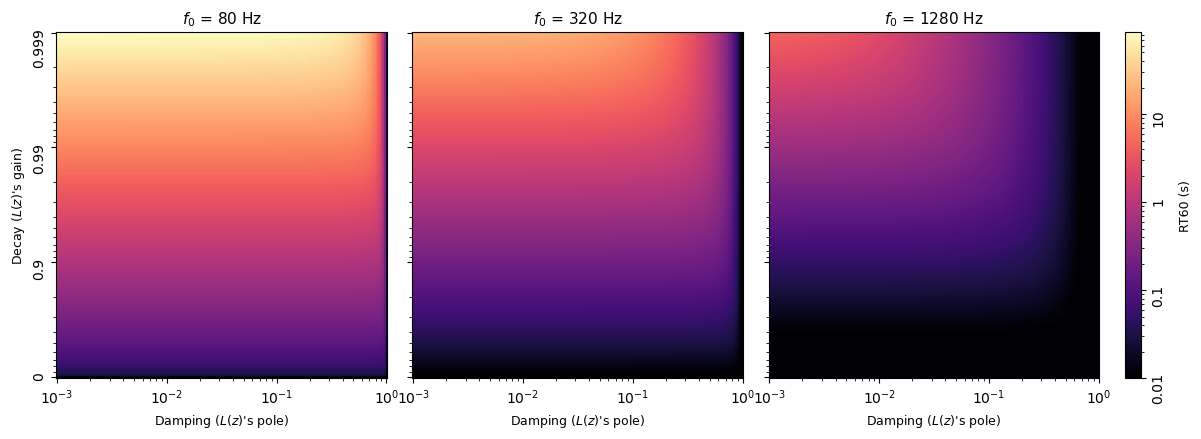

In [10]:
CMAP = 'magma'
HSPACE     = 0.1
CBAR_WIDTH = 0.05

dynamic_max = max(np.max(grid[np.isfinite(grid)]) for grid in grids.values())

fig = plt.figure(figsize=(14, 4.5))
gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1, 1, 1, CBAR_WIDTH],
    wspace=HSPACE,
)

axes = [fig.add_subplot(gs[0, 0])]
for i in range(1, 3):
    axes.append(fig.add_subplot(gs[0, i], sharey=axes[0]))
cbar_ax = fig.add_subplot(gs[0, 3])

# 2. Dynamically generate log-spaced colorbar ticks based on the new max
max_pow = int(np.ceil(np.log10(dynamic_max)))
cb_ticks = [10**p for p in range(-2, max_pow + 1)]

for col, (ax, f0) in enumerate(zip(axes, F0s)):
    # 3. Clip and normalize using the new dynamic_max
    data = np.clip(grids[f0], 1e-4, dynamic_max)

    im = ax.pcolormesh(
        a1_vals, g_complement, data,
        cmap=CMAP,
        norm=LogNorm(vmin=1e-2, vmax=dynamic_max),
        shading="auto",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_yaxis()

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f"$10^{{{int(round(np.log10(x)))}}}$" if x > 0 else ""
    ))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{1 - x:.4g}"))
    ax.tick_params(axis="y", labelrotation=90)

    ax.set_title(f"$f_0$ = {f0} Hz", fontsize=11)
    ax.set_xlabel("Damping ($L(z)$'s pole)", fontsize=9)

    if col == 0:
        ax.set_ylabel("Decay ($L(z)$'s gain)", fontsize=9)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

cb = fig.colorbar(im, cax=cbar_ax, ticks=cb_ticks)
cb.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
cb.ax.tick_params(labelrotation=90)
cb.set_label("RT60 (s)", fontsize=9, rotation=90, labelpad=10)

plt.show()